# Health Recommendation System — Text Matching & Rule Extraction

This notebook reverse-engineers the recommendation logic embedded in the dataset's free-text columns, recovering the hidden rule engine that maps health dimension values to personalised tips.

**Pipeline overview:**
1. **Consistency Validation** — Verify that `status_assessment` text is fully determined by numeric columns
2. **Tip Extraction** — Parse and deduplicate atomic recommendation sentences from raw free text
3. **Rule Decomposition** — Use frequency-variance analysis to map each tip to its controlling dimension(s)
4. **Coupling Analysis** — Identify tips jointly controlled by two dimensions via heatmap visualisation

---
> ⚠️ **Data Notice:** The original dataset (`data_sample.xlsx`) is proprietary and cannot be shared publicly.  
> A mock sample (`data_sample.xlsx`) with identical column structure is provided for reference.  
> **Outputs below were produced on the full dataset (746,496 rows) and are preserved for reproducibility.**


In [1]:
import pandas as pd

def check_all_dimensions_consistency(file_path):
    """
    Validates the consistency of status_assessment for all 8 health dimensions.
    Outputs status in English.
    """
    print(f"--- Starting Consistency Check for File: {file_path} ---")
    
    # Define the 8 dimensions from your dataset
    dimensions = [
        'nutrition', 'obesity', 'sleep', 'depression', 
        'wellness', 'anti_stress', 'anti_smoke', 'movement'
    ]
    
    # Load data - Using only necessary columns to optimize memory usage
    try:
        # Load all range columns and the text column
        cols_to_load = ['status_assessment']
        for dim in dimensions:
            cols_to_load.append(f'dif_{dim}')
            cols_to_load.append(f'c_val_{dim}')
        
        print("Loading data into memory...")
        df = pd.read_excel(file_path, usecols=cols_to_load)
        print(f"Total Rows: {len(df)}\n")
    except Exception as e:
        print(f"Error loading file: {e}")
        return

    report = {}

    for dim in dimensions:
        print(f"Validating Dimension: [{dim}]")
        
        # Define internal logic to extract the specific status of the dimension
        def get_internal_status(text, dim_name):
            label = dim_name.replace('_', ' ').capitalize()
            # Check if it belongs to "Start Improving" category
            if f"improving with respect to your {label}" in text or f"{label}" in text.split("Your progress")[0]:
                return "Level_A"
            # Check if it belongs to "Acceptable" category
            elif f"acceptable level for {label}" in text:
                return "Level_B"
            # Default to healthy/optimal
            else:
                return "Level_C"

        # Apply extraction logic
        target_label_col = f'temp_status_{dim}'
        df[target_label_col] = df['status_assessment'].apply(lambda x: get_internal_status(str(x), dim))
        
        # Group by the range inputs and check for unique status counts
        group_keys = [f'dif_{dim}', f'c_val_{dim}']
        consistency_stats = df.groupby(group_keys)[target_label_col].nunique()
        
        # Filter groups with more than 1 unique result (this indicates an error)
        conflicts = consistency_stats[consistency_stats > 1]
        
        if conflicts.empty:
            report[dim] = "PASSED"
            print(f"  Status: ✅ PASSED (Logic is consistent)")
        else:
            report[dim] = f"FAILED ({len(conflicts)} conflict groups)"
            print(f"  Status: ❌ FAILED (Found {len(conflicts)} logic inconsistencies)")
            
            # Show the first conflict case for debugging
            conflict_range = conflicts.index[0]
            print(f"  Debug Hint (First Conflict at {conflict_range}):")
            print(df[(df[group_keys[0]] == conflict_range[0]) & 
                     (df[group_keys[1]] == conflict_range[1])][['status_assessment', target_label_col]].drop_duplicates())
        
        print("-" * 40)

    # Print final summary table
    print("\n" + "="*50)
    print(f"{'DIMENSION':<20} | {'VALIDATION RESULT'}")
    print("="*50)
    for dim, result in report.items():
        print(f"{dim:<20} | {result}")
    print("="*50)

In [2]:
check_all_dimensions_consistency('data_sample.xlsx')  # replace with full dataset path to reproduce original outputs

--- Starting Consistency Check for File: dataNum575.xlsx ---
Loading data into memory...
Total Rows: 746496

Validating Dimension: [nutrition]
  Status: ✅ PASSED (Logic is consistent)
----------------------------------------
Validating Dimension: [obesity]
  Status: ✅ PASSED (Logic is consistent)
----------------------------------------
Validating Dimension: [sleep]
  Status: ✅ PASSED (Logic is consistent)
----------------------------------------
Validating Dimension: [depression]
  Status: ✅ PASSED (Logic is consistent)
----------------------------------------
Validating Dimension: [wellness]
  Status: ✅ PASSED (Logic is consistent)
----------------------------------------
Validating Dimension: [anti_stress]
  Status: ✅ PASSED (Logic is consistent)
----------------------------------------
Validating Dimension: [anti_smoke]
  Status: ✅ PASSED (Logic is consistent)
----------------------------------------
Validating Dimension: [movement]
  Status: ✅ PASSED (Logic is consistent)
--------

In [3]:
from collections import Counter

df = pd.read_excel('data_sample.xlsx', usecols=['recommendations'])
counter = Counter(df["recommendations"])
counter.most_common(20)


[('Increasing levels of physical activity: engaging in one hour of moderate physical activity per day (ex. walking) Increase your intake of NSP (dietary fibre) as it will promote weight loss.',
  2829),
 ('Restrict the intake of sugars-sweetened soft drinks. Increasing levels of physical activity: engaging in one hour of moderate physical activity per day (ex. walking)',
  2804),
 ('Increasing levels of physical activity: engaging in one hour of moderate physical activity per day (ex. walking) Restrict the intake of sugars-sweetened soft drinks.',
  2801),
 ('Increase your intake of NSP (dietary fibre) as it will promote weight loss. Restrict the intake of sugars-sweetened soft drinks.',
  2782),
 ('Restrict the intake of sugars-sweetened soft drinks. Increase your intake of NSP (dietary fibre) as it will promote weight loss.',
  2766),
 ('Restrict the intake of sugars-sweetened soft drinks. Don’t spend too much time in one place, take breaks often to walk around or stretch.',
  2730),

In [4]:
import re

sentences = set()

for text in df["recommendations"]:
    parts = re.split(r'\.\s+', text)
    for p in parts:
        p = p.strip()
        if len(p) > 20:
            sentences.add(p)
list(sentences)[:20]

['Pick up a nice plushy to help you sleep  Try to pick up some hobbies that make you happy Get a journal and write your thoughts out When facing great challenges, try to look at them as opportunities for personal growth',
 'walking) Get a journal and write your thoughts out Share your feelings with a trusted friend in person or talk to a psychologist.Develop habits, or a regular schedule.',
 'Pick up a nice plushy to help you sleep  Realize that your situation is temporary and time will eventually heal your situation Try to pick up some hobbies that make you happy Chew gum or eat mints when you feel the urge to smoke',
 'Pick up a nice plushy to help you sleep  Refrain from using electronics or looking at bright lights at least an hour before you sleep.',
 'walking) Try to pick up some hobbies that make you happy Realize that your situation is temporary and time will eventually heal your situation Avoid harmful behaviors, such as smoking and excessive drinking',
 'Realize that your sit

In [5]:
len(sentences)

829

In [6]:
import re

sentences = set()

END_PATTERNS = [
    r'Get a journal and write your thoughts out',
    r'Increasing levels of physical activity: engaging in one hour of moderate physical activity per day \(ex\. walking\)',
    r'Making a schedule and following it can help you feel less overwhelmed',
    r'Pick up a nice plushy to help you sleep',
    r'Realize that your situation is temporary and time will eventually heal your situation',
    r'Try to pick up some hobbies that make you happy'
]

end_regex = r'(' + '|'.join(END_PATTERNS) + r')(?=\s+[A-Z])'

for text in df["recommendations"].dropna():

    text = text.strip()

    text = re.sub(end_regex, r'\1.', text)

    if not text.endswith('.'):
        text = text + '.'

    parts = re.split(r'(?<!ex)[.!]\s*', text)

    for part in parts:
        part = part.strip()
        if part == "":
            continue

        part = re.sub(r'[.!]+$', '', part).strip()

        sentences.add(part)

print("Unique sentence count:", len(sentences))
sentences

Unique sentence count: 33


{'Anticipate and plan for the challenges that may arise',
 'Avoid harmful behaviors, such as smoking and excessive drinking',
 'Avoid who stress you out: If someone is constantly causing stress in your  life and you cannot break the relationship, limit the time you spend with it, or break the relationship completely if possible',
 'Change your mindset',
 'Chew gum or eat mints when you feel the urge to smoke',
 'Develop habits, or a regular schedule',
 'Do things that make you happy',
 'Don’t spend too much time in one place, take breaks often to walk around or stretch',
 'Drink plenty of water',
 'For example, when you’re stuck in traffic, look at it as an opportunity to pause and listen to your favorite radio station',
 'Get a journal and write your thoughts out',
 'Get at least seven hours of sleep per night',
 'Increase your intake of NSP (dietary fibre) as it will promote weight loss',
 'Increasing levels of physical activity: engaging in one hour of moderate physical activity per

---
## Step 2 — Tip Extraction

The `recommendations` column concatenates multiple tips into a single string **without consistent delimiters**.  
The core challenge: some tips contain internal periods (e.g. `"ex. walking"`), which causes naive `.split('.')` to break mid-sentence.

**Design decision — END_PATTERNS anchor approach:**  
Instead of a generic splitter, we define a list of known tips that end without a period, and inject a period after each via regex *before* splitting. This preserves sentence integrity while correctly segmenting the rest.

*Cell 4 below shows the naive approach (829 broken fragments) — Cell 6 shows the fixed version (33 clean sentences).*


In [7]:
import pandas as pd
from itertools import combinations

sentence_list = list(sentences)

presence = []

for text in df["recommendations"].dropna():
    row = {}
    for s in sentence_list:
        row[s] = int(s in text)
    presence.append(row)

presence_df = pd.DataFrame(presence)

always_together = []

for s1, s2 in combinations(sentence_list, 2):

    c1 = presence_df[s1].sum()
    c2 = presence_df[s2].sum()
    c12 = ((presence_df[s1] == 1) & (presence_df[s2] == 1)).sum()

    if c1 == c2 == c12 and c1 > 0:
        always_together.append((s1, s2))

print(always_together)


[('Develop habits, or a regular schedule', 'Share your feelings with a trusted friend in person or talk to a psychologist'), ('They can keep you accountable', 'Tell your family and friends that you plan to quit smoking'), ('Change your mindset', 'Try to look at problems from a positive perspective'), ('Change your mindset', 'For example, when you’re stuck in traffic, look at it as an opportunity to pause and listen to your favorite radio station'), ('Try to look at problems from a positive perspective', 'For example, when you’re stuck in traffic, look at it as an opportunity to pause and listen to your favorite radio station')]


In [8]:
presence_df[
    [
        "For example, when you’re stuck in traffic, look at it as an opportunity to pause and listen to your favorite radio station",
        "Change your mindset",
        "Try to look at problems from a positive perspective"
    ]
].drop_duplicates()


,"For example, when you’re stuck in traffic, look at it as an opportunity to pause and listen to your favorite radio station",Change your mindset,Try to look at problems from a positive perspective
0,0,0,0
10369,1,1,1


In [24]:
import networkx as nx
import re

G = nx.Graph()
G.add_nodes_from(sentence_list)

for s1, s2 in always_together:
    G.add_edge(s1, s2)

# 1. Initialize container for merged groups
groups = list(nx.connected_components(G))
final_tips_list = []

# Record all atomic sentences that have been merged
merged_members = set()

# 2. Process groups of sentences that should be merged
for group in groups:
    group = list(group)
    if len(group) <= 1:
        continue
        
    # Find an original text entry that contains all fragments in the group
    # Using the original slicing preserves punctuation between fragments
    for text in df["recommendations"].dropna():
        if all(s in text for s in group):
            positions = []
            for s in group:
                start_idx = text.find(s)
                if start_idx != -1:
                    positions.append((start_idx, start_idx + len(s)))
            
            positions.sort()
            
            # Extract the continuous span from the first fragment to the last
            # This automatically keeps punctuation like "ex. " or ". "
            full_merged = text[positions[0][0] : positions[-1][1]].strip()
            
            final_tips_list.append(full_merged)
            merged_members.update(group)
            break

# 3. Add isolated sentences that were not merged
for s in sentence_list:
    if s not in merged_members:
        final_tips_list.append(s)

# 4. Core optimization: remove trailing punctuation and ensure uniqueness
# Regex [.!]+$ removes any ending periods or exclamation marks
final_processed_tips = set()

for tip in final_tips_list:
    clean_tip = re.sub(r'[.!]+$', '', tip.strip()).strip()
    
    if clean_tip:
        final_processed_tips.add(clean_tip)

# 5. Update global variable
updated_sentences = final_processed_tips

print(f"Original number of fragments: {len(sentence_list)}")
print(f"Final number of Base Tips after merging and punctuation removal: {len(updated_sentences)}")

# Print results for inspection
for i, tip in enumerate(sorted(list(updated_sentences))):
    print(f"{i+1}: {tip}")

Original number of fragments: 33
Final number of Base Tips after merging and punctuation removal: 29
1: Anticipate and plan for the challenges that may arise
2: Avoid harmful behaviors, such as smoking and excessive drinking
3: Avoid who stress you out: If someone is constantly causing stress in your  life and you cannot break the relationship, limit the time you spend with it, or break the relationship completely if possible
4: Change your mindset. Try to look at problems from a positive perspective. For example, when you’re stuck in traffic, look at it as an opportunity to pause and listen to your favorite radio station
5: Chew gum or eat mints when you feel the urge to smoke
6: Do things that make you happy
7: Don’t spend too much time in one place, take breaks often to walk around or stretch
8: Drink plenty of water
9: Get a journal and write your thoughts out
10: Get at least seven hours of sleep per night
11: Increase your intake of NSP (dietary fibre) as it will promote weight l

---
### Fragment Merging via Graph Analysis

After extraction, some tips were split into 2–3 fragments that always appear together (e.g. `"Change your mindset"` and `"Try to look at problems from a positive perspective"` are always co-occurring sub-parts of one tip).

**Approach:** Build a graph where nodes = sentences, edges = always-together pairs. Connected components identify fragment groups → merge back into one canonical tip by recovering the original span from source text.


In [10]:
import pandas as pd

A = "Develop habits, or a regular schedule"
B = "Share your feelings with a trusted friend in person or talk to a psychologist"

subset = df[df["recommendations"].str.contains(A, na=False)]

total_A = len(subset)

order_counts = {
    "A_before_B": 0,
    "B_before_A": 0
}

for text in subset["recommendations"]:

    if B not in text:
        print("❌ Found A without B!")
        break

    posA = text.find(A)
    posB = text.find(B)

    if posA < posB:
        order_counts["A_before_B"] += 1
    else:
        order_counts["B_before_A"] += 1

print("Total A occurrences:", total_A)
print("Order counts:", order_counts)


Total A occurrences: 99305
Order counts: {'A_before_B': 0, 'B_before_A': 99305}


Loading Sleep dimension data...
Calculating distribution matrix...

--- Sensitivity Analysis (Top Variance) ---


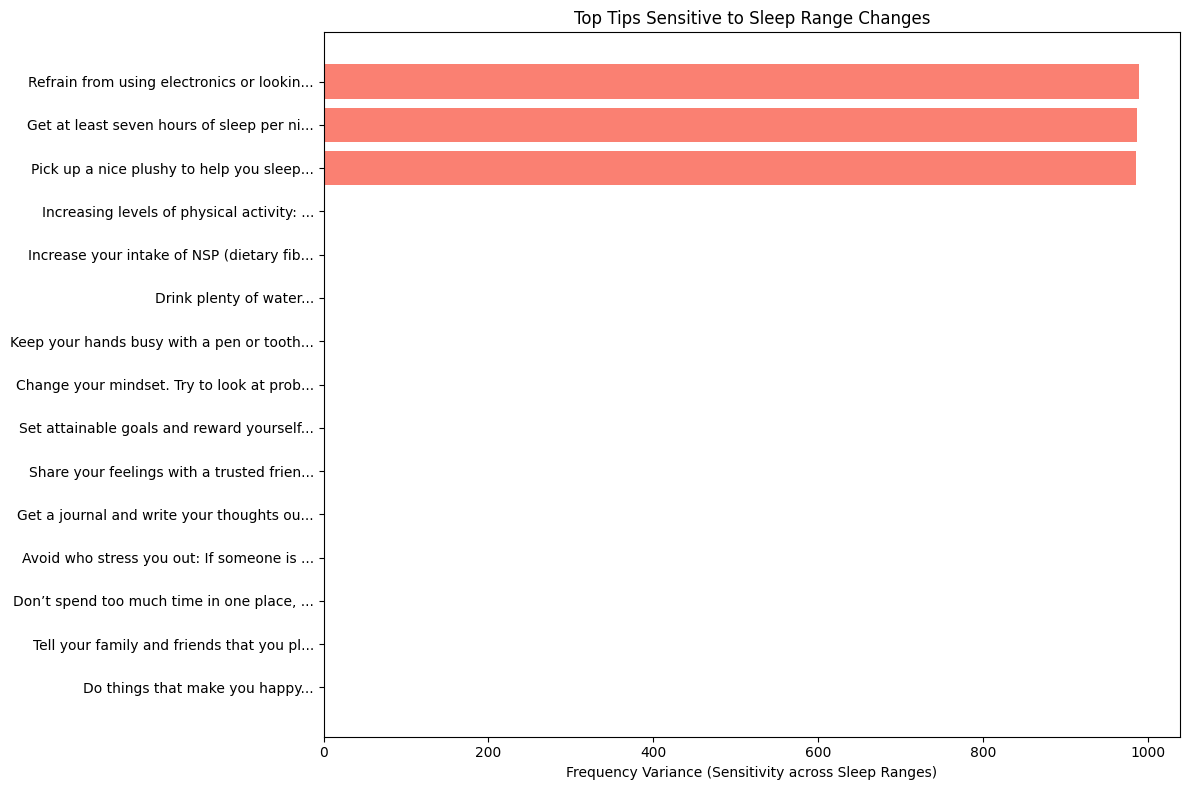

Base Tip Sentence                                            | R0(%) | R1(%) | R2(%) | Variance
--------------------------------------------------------------------------------------------------------------
Refrain from using electronics or looking at bright lights   |  66.75 |  66.72 |   0.00 |   989.61
Get at least seven hours of sleep per night                  |  66.61 |  66.69 |   0.00 |   987.12
Pick up a nice plushy to help you sleep                      |  66.64 |  66.60 |   0.00 |   986.23
Increasing levels of physical activity: engaging in one ho   |  49.90 |  49.92 |  50.32 |     0.04
Increase your intake of NSP (dietary fibre) as it will pro   |  50.17 |  50.11 |  49.75 |     0.03
Drink plenty of water                                        |  16.59 |  16.84 |  16.73 |     0.01
Keep your hands busy with a pen or toothpick                 |  11.00 |  11.15 |  11.20 |     0.01
Change your mindset. Try to look at problems from a positi   |  16.75 |  16.59 |  16.57 |     0.01
S

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def analyze_sleep_impact_diff(file_path, updated_sentences):
    print("Loading Sleep dimension data...")
    cols = ['dif_sleep', 'c_val_sleep', 'recommendations']
    df = pd.read_excel(file_path, usecols=cols)
    
    df['range_key'] = df['dif_sleep'].astype(str) + " | " + df['c_val_sleep'].astype(str)
    ranges = df['range_key'].unique()

    # stats: {sentence: [freq_in_range1, freq_in_range2, freq_in_range3]}
    sentence_distribution = defaultdict(lambda: [0.0] * len(ranges))
    range_to_idx = {r_key: i for i, r_key in enumerate(ranges)}
    range_counts = df['range_key'].value_counts().to_dict()

    print("Calculating distribution matrix...")
    for r_key in ranges:
        subset = df[df['range_key'] == r_key]['recommendations'].astype(str)
        total_rows = range_counts[r_key]
        idx = range_to_idx[r_key]
        
        for s in updated_sentences:
            count = subset.str.contains(s, regex=False).sum()
            sentence_distribution[s][idx] = (count / total_rows) * 100

    diff_results = []
    for s, freqs in sentence_distribution.items():
        variance = np.var(freqs)
        mean_freq = np.mean(freqs)
        diff_results.append({
            'sentence': s,
            'frequencies': freqs,
            'variance': variance,
            'avg_freq': mean_freq
        })

    diff_results = sorted(diff_results, key=lambda x: x['variance'], reverse=True)

    print("\n--- Sensitivity Analysis (Top Variance) ---")
    top_diff = diff_results[:15] 
    
    plt.figure(figsize=(12, 8))
    labels = [f"{d['sentence'][:40]}..." for d in top_diff]
    variances = [d['variance'] for d in top_diff]
    
    plt.barh(labels, variances, color='salmon')
    plt.xlabel('Frequency Variance (Sensitivity across Sleep Ranges)')
    plt.title('Top Tips Sensitive to Sleep Range Changes')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print(f"{'Base Tip Sentence':<60} | " + " | ".join([f"R{i}(%)" for i in range(len(ranges))]) + " | Variance")
    print("-" * 110)
    for d in diff_results:
        if d['avg_freq'] > 1:
            freq_str = " | ".join([f"{f:6.2f}" for f in d['frequencies']])
            print(f"{d['sentence'][:58]:<60} | {freq_str} | {d['variance']:8.2f}")

analyze_sleep_impact_diff('data_sample.xlsx', updated_sentences)

--- Loading Movement Data ---
Analyzing 12 distinct ranges...

Base Tip Sentence                                       | (-1000)-(-250)  | (-1000)-(-250)  | (-1000)-(-250)  | (-250)-0 | 0-40 | (-250)-0 | 400- | (-250)-0 | 600- | 0-250 | 0-400 | 0-250 | 400-600 | 0-250 | 600-100 | 250-1000 | 0-40 | 250-1000 | 400- | 250-1000 | 600- | Variance
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
You must engage in at least 30 minutes of moderate ph   |           50.49 |           50.12 |            0.00 |           50.00 |           50.26 |            0.00 |            0.00 |            0.00 |            0.00 |            0.00 |            0.00 |            0.00 |   560.37
Take a post-meal walk                                   |           49.82 |           50.19 

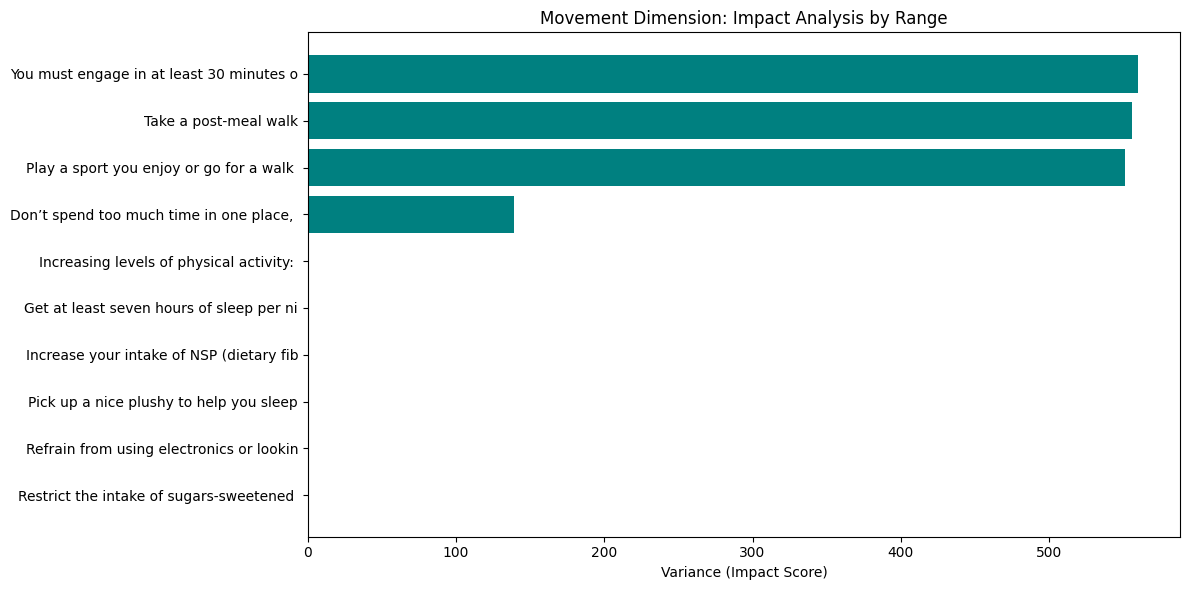

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def analyze_movement_with_labels(file_path, updated_sentences):
    print("--- Loading Movement Data ---")
    cols = ['dif_movement', 'c_val_movement', 'recommendations']
    df = pd.read_excel(file_path, usecols=cols)
    
    df['range_label'] = df['dif_movement'].astype(str) + " | " + df['c_val_movement'].astype(str)
    
    unique_labels = sorted(df['range_label'].unique())
    range_counts = df['range_label'].value_counts().to_dict()
    
    sentence_distribution = defaultdict(lambda: [0.0] * len(unique_labels))
    label_to_idx = {label: i for i, label in enumerate(unique_labels)}

    print(f"Analyzing {len(unique_labels)} distinct ranges...")

    for label in unique_labels:
        subset = df[df['range_label'] == label]['recommendations'].astype(str)
        total_rows = range_counts[label]
        idx = label_to_idx[label]
        
        for s in updated_sentences:
            count = subset.str.contains(s, regex=False).sum()
            sentence_distribution[s][idx] = (count / total_rows) * 100

    diff_results = []
    for s, freqs in sentence_distribution.items():
        diff_results.append({
            'sentence': s,
            'frequencies': freqs,
            'variance': np.var(freqs),
            'avg_freq': np.mean(freqs)
        })

    diff_results = sorted(diff_results, key=lambda x: x['variance'], reverse=True)

    header_labels = [f"{label[:15]}" for label in unique_labels]
    header = f"{'Base Tip Sentence':<55} | " + " | ".join(header_labels) + " | Variance"
    print("\n" + "="*len(header))
    print(header)
    print("-" * len(header))
    
    for d in diff_results:
        if d['avg_freq'] > 0.5:
            freq_str = " | ".join([f"{f:15.2f}" for f in d['frequencies']])
            print(f"{d['sentence'][:53]:<55} | {freq_str} | {d['variance']:8.2f}")

    plt.figure(figsize=(12, 6))
    top_v = diff_results[:10]
    plt.barh([v['sentence'][:40] for v in top_v], [v['variance'] for v in top_v], color='teal')
    plt.xlabel('Variance (Impact Score)')
    plt.title('Movement Dimension: Impact Analysis by Range')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

analyze_movement_with_labels('data_sample.xlsx', updated_sentences)

In [13]:
import pandas as pd
import numpy as np
from collections import defaultdict

def get_movement_freq_matrix(file_path, updated_sentences):

    cols = ['dif_movement', 'c_val_movement', 'recommendations']
    df = pd.read_excel(file_path, usecols=cols)

    unique_difs = sorted(df['dif_movement'].unique())
    unique_cvals = sorted(df['c_val_movement'].unique())

    results = defaultdict(dict)

    counts_map = df.groupby(['dif_movement', 'c_val_movement']).size().to_dict()

    print("Calculating frequencies for all combinations...")
    for (dif, cval), count in counts_map.items():
        subset = df[(df['dif_movement'] == dif) & (df['c_val_movement'] == cval)]['recommendations'].astype(str)
        
        for s in updated_sentences:
            s_count = subset.str.contains(s, regex=False).sum()
            results[s][(dif, cval)] = (s_count / count) * 100

    res_df = pd.DataFrame(results).T
    res_df.columns = pd.MultiIndex.from_tuples(res_df.columns, names=['dif', 'c_val'])
    
    return res_df

movement_matrix = get_movement_freq_matrix('data_sample.xlsx', updated_sentences)

Calculating frequencies for all combinations...


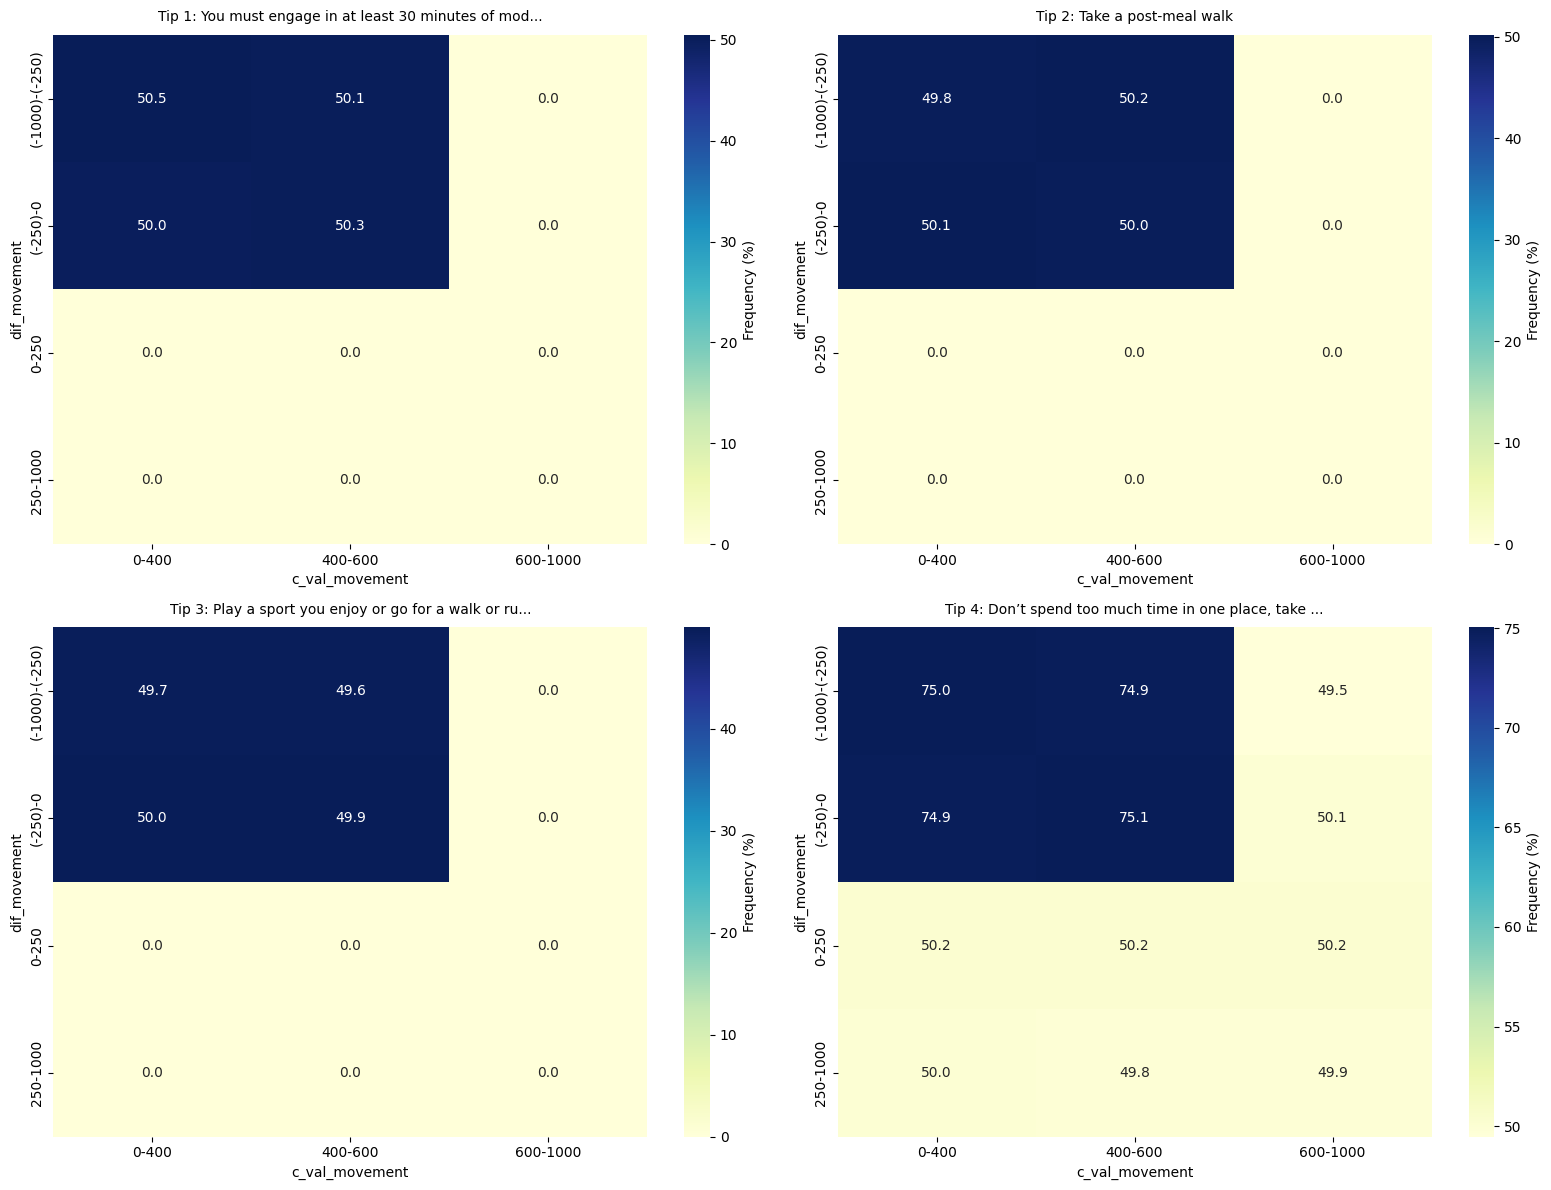

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

variances = movement_matrix.var(axis=1).sort_values(ascending=False)
top_4_sentences = variances.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, sentence in enumerate(top_4_sentences):

    data_slice = movement_matrix.loc[sentence].unstack(level='c_val')

    sns.heatmap(data_slice, 
                annot=True, 
                fmt=".1f", 
                cmap="YlGnBu", 
                ax=axes[i], 
                cbar_kws={'label': 'Frequency (%)'})

    short_title = (sentence[:45] + '...') if len(sentence) > 45 else sentence
    axes[i].set_title(f"Tip {i+1}: {short_title}", fontsize=10, pad=10)
    axes[i].set_xlabel("c_val_movement")
    axes[i].set_ylabel("dif_movement")

plt.tight_layout()
plt.show()

--- Loading Anti_Smoke Data ---
Analyzing 12 distinct ranges...
Base Tip Sentence                                            | R0(%) | R1(%) | R2(%) | R3(%) | R4(%) | R5(%) | R6(%) | R7(%) | R8(%) | R9(%) | R10(%) | R11(%) | Variance
--------------------------------------------------------------------------------------------------------------
Anticipate and plan for the challenges that may arise        |  33.39 |  33.13 |   0.00 |  33.56 |  33.60 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   248.18
Avoid harmful behaviors, such as smoking and excessive dri   |  33.40 |  33.65 |   0.00 |  33.08 |  33.52 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   248.12
Chew gum or eat mints when you feel the urge to smoke        |  33.24 |  33.23 |   0.00 |  33.28 |  33.64 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   0.00 |   247.11
Keep your hands busy with a pen or toothpick                 |  33.64 |  33.24 |   0.00 |  33.39 |  33.12 |   0.00 

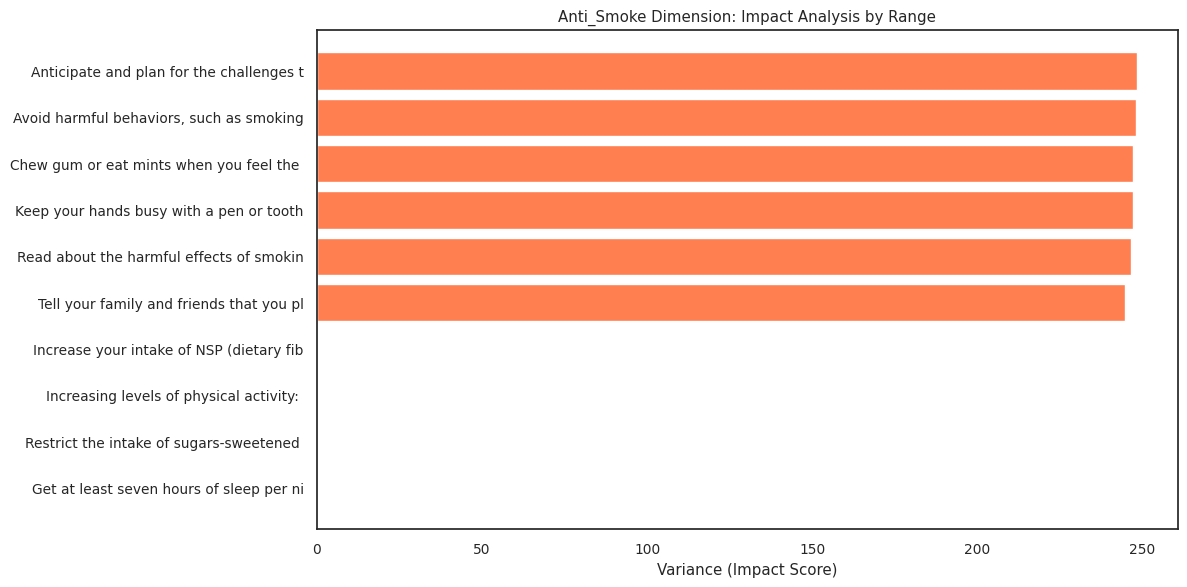

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def analyze_anti_smoke_with_labels(file_path, updated_sentences):
    print("--- Loading Anti_Smoke Data ---")
    cols = ['dif_anti_smoke', 'c_val_anti_smoke', 'recommendations']
    df = pd.read_excel(file_path, usecols=cols)
    df['range_label'] = df['dif_anti_smoke'].astype(str) + " | " + df['c_val_anti_smoke'].astype(str)
    unique_labels = sorted(df['range_label'].unique())
    range_counts = df['range_label'].value_counts().to_dict()
    sentence_distribution = defaultdict(lambda: [0.0] * len(unique_labels))
    label_to_idx = {label: i for i, label in enumerate(unique_labels)}
    print(f"Analyzing {len(unique_labels)} distinct ranges...")
    for label in unique_labels:
        subset = df[df['range_label'] == label]['recommendations'].astype(str)
        total_rows = range_counts[label]
        idx = label_to_idx[label]
        for s in updated_sentences:
            count = subset.str.contains(s, regex=False).sum()
            sentence_distribution[s][idx] = (count / total_rows) * 100
    diff_results = []
    for s, freqs in sentence_distribution.items():
        diff_results.append({
            'sentence': s, 'frequencies': freqs,
            'variance': np.var(freqs), 'avg_freq': np.mean(freqs)
        })
    diff_results = sorted(diff_results, key=lambda x: x['variance'], reverse=True)
    return diff_results, unique_labels

# Step 1: Call function
diff_results, ranges = analyze_anti_smoke_with_labels('data_sample.xlsx', updated_sentences)

# Step 2: Print table
print(f"{'Base Tip Sentence':<60} | " + " | ".join([f"R{i}(%)" for i in range(len(ranges))]) + " | Variance")
print("-" * 110)
for d in diff_results:
    if d['avg_freq'] > 1:
        freq_str = " | ".join([f"{f:6.2f}" for f in d['frequencies']])
        print(f"{d['sentence'][:58]:<60} | {freq_str} | {d['variance']:8.2f}")

# Step 3: One chart only
plt.figure(figsize=(12, 6))
top_v = diff_results[:10]
plt.barh([v['sentence'][:40] for v in top_v], [v['variance'] for v in top_v], color='coral')
plt.xlabel('Variance (Impact Score)')
plt.title('Anti_Smoke Dimension: Impact Analysis by Range')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np

all_dims = ['nutrition', 'obesity', 'sleep', 'depression', 'wellness', 'anti_stress', 'anti_smoke', 'movement']
load_cols = []
for d in all_dims:
    load_cols.extend([f'dif_{d}', f'c_val_{d}'])
load_cols.append('recommendations')

df_full = pd.read_excel('data_sample.xlsx', usecols=load_cols)

target_tip = 'Don’t spend too much time in one place, take breaks often to walk around or stretch'
df_full['target_hit'] = df_full['recommendations'].astype(str).str.contains(target_tip, regex=False).astype(int)

mask_75 = (
    (df_full['dif_movement'].isin(['(-1000)-(-250)', '(-250)-0'])) & 
    (df_full['c_val_movement'].isin(['0-400', '400-600']))
)

df_75 = df_full[mask_75].copy()
df_50 = df_full[~mask_75].copy()

print(f"Dataset split: Group_75 count = {len(df_75)}, Group_50 count = {len(df_50)}")

Dataset split: Group_75 count = 248832, Group_50 count = 497664


In [16]:
import matplotlib.pyplot as plt
import pandas as pd

test_dimensions = ['nutrition', 'obesity', 'sleep', 'depression', 'wellness', 'anti_stress', 'anti_smoke']

stability_summary = []

print("--- Starting Global Independence Scan ---")

for dim in test_dimensions:
    col_name = f'dif_{dim}'
    
    stats_75 = df_75.groupby(col_name)['target_hit'].mean()

    stats_50 = df_50.groupby(col_name)['target_hit'].mean()
    
    stability_summary.append({
        'Dimension': dim,
        'G75_Mean': stats_75.mean(),
        'G75_Range_Gap': stats_75.max() - stats_75.min(),
        'G50_Mean': stats_50.mean(),
        'G50_Range_Gap': stats_50.max() - stats_50.min()
    })

    print(f"\nChecking [{dim}]:")
    print(f"  Group_75 frequencies: {stats_75.values.round(4)}")
    print(f"  Group_50 frequencies: {stats_50.values.round(4)}")

summary_df = pd.DataFrame(stability_summary)
print("\n--- Final Stability Report ---")
print(summary_df)

--- Starting Global Independence Scan ---

Checking [nutrition]:
  Group_75 frequencies: [0.7498]
  Group_50 frequencies: [0.4998]

Checking [obesity]:
  Group_75 frequencies: [0.7498]
  Group_50 frequencies: [0.4998]

Checking [sleep]:
  Group_75 frequencies: [0.7498]
  Group_50 frequencies: [0.4998]

Checking [depression]:
  Group_75 frequencies: [0.7477 0.7497 0.7508 0.7509]
  Group_50 frequencies: [0.4995 0.4987 0.4995 0.5015]

Checking [wellness]:
  Group_75 frequencies: [0.7502 0.7505 0.7508 0.7476]
  Group_50 frequencies: [0.4995 0.5014 0.4993 0.499 ]

Checking [anti_stress]:
  Group_75 frequencies: [0.751  0.7479 0.7501 0.7501]
  Group_50 frequencies: [0.5015 0.4992 0.4986 0.5   ]

Checking [anti_smoke]:
  Group_75 frequencies: [0.7475 0.7505 0.7518 0.7493]
  Group_50 frequencies: [0.5012 0.4995 0.4984 0.5001]

--- Final Stability Report ---
     Dimension  G75_Mean  G75_Range_Gap  G50_Mean  G50_Range_Gap
0    nutrition  0.749775       0.000000  0.499807       0.000000
1      o

In [17]:
group_a = [
    "You must engage in at least 30 minutes of moderate physical activity such as brisk walking or aerobic exercise every day",
    "Take a post-meal walk",
    "Play a sport you enjoy or go for a walk or run"
]
group_b = [
    "Don’t spend too much time in one place, take breaks often to walk around or stretch"
]

target_data = df_75.copy()

print("Counting occurrences per row...")
target_data['count_a'] = 0
for s in group_a:
    target_data['count_a'] += target_data['recommendations'].astype(str).str.contains(s, regex=False).astype(int)

target_data['count_b'] = 0
for s in group_b:
    target_data['count_b'] += target_data['recommendations'].astype(str).str.contains(s, regex=False).astype(int)

target_data['total_movement_tips'] = target_data['count_a'] + target_data['count_b']

contingency_table = pd.crosstab(target_data['count_b'], target_data['count_a'], margins=True)

print("\n--- Joint Occurrence Matrix (Count B vs Count A) ---")
print(contingency_table)

print("\n--- Distribution of Total Movement Tips (A + B) ---")
print(target_data['total_movement_tips'].value_counts(normalize=True).sort_index() * 100)

Counting occurrences per row...

--- Joint Occurrence Matrix (Count B vs Count A) ---
count_a       1       2     All
count_b                        
0             0   62264   62264
1        124313   62255  186568
All      124313  124519  248832

--- Distribution of Total Movement Tips (A + B) ---
total_movement_tips
2    74.981112
3    25.018888
Name: proportion, dtype: float64


In [18]:
import pandas as pd
import numpy as np
from collections import defaultdict

def decompose_rules(file_path, base_tips):
    dimensions = ['nutrition', 'obesity', 'sleep', 'depression', 'wellness', 'anti_stress', 'anti_smoke', 'movement']
    
    # Store final relationships
    # { dim: { tip: { 'active_condition': [], 'active_freq': x, 'background_freq': y } } }
    dim_tip_profiles = defaultdict(dict)
    
    print("--- Starting Automated Logic Decomposition ---")

    for dim in dimensions:
        # 1. Load only relevant columns
        cols = [f'dif_{dim}', f'c_val_{dim}', 'recommendations']
        df = pd.read_excel(file_path, usecols=cols)
        df['range'] = df[f'dif_{dim}'].astype(str) + " | " + df[f'c_val_{dim}'].astype(str)
        
        range_counts = df['range'].value_counts()
        unique_ranges = range_counts.index.tolist()

        for tip in base_tips:
            # 2. Compute the frequency of this tip across all ranges
            freqs = []
            range_to_freq = {}
            for r in unique_ranges:
                subset = df[df['range'] == r]
                f = (subset['recommendations'].astype(str).str.contains(tip, regex=False).sum() / len(subset)) * 100
                freqs.append(f)
                range_to_freq[r] = f
            
            # 3. Use variance to determine if the tip is influenced by this dimension
            variance = np.var(freqs)
            
            if variance > 10:  # Threshold chosen empirically: constant tips ≈ 0, rule-driven tips range 50–2500ingful variation
                # Identify active and background ranges
                avg_f = np.mean(freqs)
                active_ranges = [r for r, f in range_to_freq.items() if f > avg_f + 5]
                inactive_ranges = [r for r, f in range_to_freq.items() if f < avg_f]
                
                # Compute average frequencies
                active_freq = np.mean([range_to_freq[r] for r in active_ranges]) if active_ranges else 0
                bg_freq = np.mean([range_to_freq[r] for r in inactive_ranges]) if inactive_ranges else 0

                dim_tip_profiles[dim][tip] = {
                    'active_conditions': active_ranges,
                    'active_freq': round(active_freq, 2),
                    'background_freq': round(bg_freq, 2),
                    'variance': round(variance, 2)
                }
        
        print(f"Dimension [{dim}] decomposition completed. Number of associated Tips: {len(dim_tip_profiles[dim])}")
        del df  # Free memory
    
    return dim_tip_profiles

# Run decomposition
dim_profiles = decompose_rules('data_sample.xlsx', list(updated_sentences))

--- Starting Automated Logic Decomposition ---
Dimension [nutrition] decomposition completed. Number of associated Tips: 0
Dimension [obesity] decomposition completed. Number of associated Tips: 0
Dimension [sleep] decomposition completed. Number of associated Tips: 3
Dimension [depression] decomposition completed. Number of associated Tips: 5
Dimension [wellness] decomposition completed. Number of associated Tips: 4
Dimension [anti_stress] decomposition completed. Number of associated Tips: 5
Dimension [anti_smoke] decomposition completed. Number of associated Tips: 6
Dimension [movement] decomposition completed. Number of associated Tips: 4


---
## Step 3 — Rule Decomposition via Frequency-Variance Analysis

**Core insight:** If a tip's appearance frequency varies significantly across different value ranges of a dimension, that dimension controls the tip.

For each `(tip, dimension)` pair:
- Compute tip appearance rate (%) per unique `dif_dim × c_val_dim` range combination
- Compute variance across all ranges
- **Variance > 10** → dimension influences this tip *(threshold chosen empirically: constant tips have variance ≈ 0, rule-driven tips show variance 50–2500)*
- **Type A** tip: background frequency = 0 (tip only appears when dimension is active)  
- **Type B** tip: non-zero background frequency (tip appears at baseline but intensifies with dimension)


In [19]:
# 1. Extract all Tips that have already been mapped in dimensions
mapped_tips = set()
for dim in dim_profiles:
    for tip in dim_profiles[dim]:
        mapped_tips.add(tip)

# 2. Convert to sets for comparison
all_tips = set(updated_sentences)
missing_tips = all_tips - mapped_tips

# 3. Output report
print(f"--- Matching Status Summary ---")
print(f"Total number of original Base Tips: {len(all_tips)}")
print(f"Total number of successfully mapped Tips: {len(mapped_tips)}")
print(f"Number of missing Tips: {len(missing_tips)}")

if missing_tips:
    print("\nThe following Base Tips are missing:")
    for i, tip in enumerate(missing_tips, 1):
        print(f"{i}. {tip}")
else:
    print("\nGreat! All Tips have been successfully mapped.")

--- Matching Status Summary ---
Total number of original Base Tips: 29
Total number of successfully mapped Tips: 26
Number of missing Tips: 3

The following Base Tips are missing:
1. Increase your intake of NSP (dietary fibre) as it will promote weight loss
2. Restrict the intake of sugars-sweetened soft drinks
3. Increasing levels of physical activity: engaging in one hour of moderate physical activity per day (ex. walking)


In [20]:
def show_dim_profiles_by_ab_logic(dim_profiles):
    print(f"{'Dimension':<15} | {'Type':<6} | {'Active%':<8} | {'BG%':<6} | {'Base Tip Sentence'}")
    print("-" * 110)
    
    for dim, tips in dim_profiles.items():
        sorted_tips = sorted(tips.items(), key=lambda x: x[1]['background_freq'])
        
        for tip, info in sorted_tips:
            act_f = info['active_freq']
            bg_f = info['background_freq']

            if bg_f == 0:
                tip_type = "A"
            else:
                tip_type = "B"
                
            short_tip = (tip[:65] + "..") if len(tip) > 65 else tip
            print(f"{dim:<15} | {tip_type:<6} | {act_f:<8.1f} | {bg_f:<6.1f} | {short_tip}")
        print("-" * 110)

show_dim_profiles_by_ab_logic(dim_profiles)

Dimension       | Type   | Active%  | BG%    | Base Tip Sentence
--------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------
sleep           | A      | 66.6     | 0.0    | Pick up a nice plushy to help you sleep
sleep           | A      | 66.7     | 0.0    | Get at least seven hours of sleep per night
sleep           | A      | 66.7     | 0.0    | Refrain from using electronics or looking at bright lights at lea..
--------------------------------------------------------------------------------------------------------------
depression      | A      | 40.0     | 0.0    | Get a journal and write your thoughts out
depression      | A      | 39.9     | 0.0    | Realize that your situation is temporary and time will eventua

---
### Verifying Constant Tips

3 tips were not mapped to any dimension — this means they appear at a **fixed rate regardless of all dimension values**.  
`verify_global_constancy_v2` confirms this by checking that std ≈ 0 across every dimension's range combinations.  
These are *global constant tips* included in every recommendation regardless of health status.


In [21]:
import pandas as pd
import numpy as np

def verify_global_constancy_v2(file_path, missing_tips, dimensions):
    verification_report = []

    all_cols = ['recommendations']
    for d in dimensions:
        all_cols.extend([f'dif_{d}', f'c_val_{d}'])
    
    print("Loading data...")
    df_all = pd.read_excel(file_path, usecols=all_cols)

    for tip in missing_tips:
        feature_text = tip[:30]
        hit_mask = df_all['recommendations'].str.contains(feature_text, regex=False, na=False)
        
        row = {'Tip': tip[:40] + "..."}
        
        for dim in dimensions:
            d_col = f'dif_{dim}'
            c_col = f'c_val_{dim}'

            group_stats = hit_mask.groupby([df_all[d_col], df_all[c_col]]).mean() * 100
            
            mean_freq = group_stats.mean()
            std_dev = group_stats.std() 
            
            row[f'{dim}_avg'] = round(mean_freq, 2)
            row[f'{dim}_std'] = round(std_dev, 4) if not np.isnan(std_dev) else 0
            
        verification_report.append(row)
    
    return pd.DataFrame(verification_report)

report = verify_global_constancy_v2('data_sample.xlsx', missing_tips, all_dims)
report

Loading data...


,Tip,nutrition_avg,nutrition_std,obesity_avg,obesity_std,sleep_avg,sleep_std,depression_avg,depression_std,wellness_avg,wellness_std,anti_stress_avg,anti_stress_std,anti_smoke_avg,anti_smoke_std,movement_avg,movement_std
0,Increase your intake of NSP (dietary fib...,50.01,0,50.01,0,50.01,0.2279,50.01,0.1752,50.01,0.2656,50.01,0.1494,50.01,0.2317,50.01,0.2028
1,Restrict the intake of sugars-sweetened ...,49.98,0,49.98,0,49.98,0.0363,49.98,0.2677,49.98,0.1201,49.98,0.3057,49.98,0.2075,49.98,0.1580
2,Increasing levels of physical activity: ...,50.05,0,50.05,0,50.05,0.2335,50.05,0.1926,50.05,0.1950,50.05,0.1683,50.05,0.2156,50.05,0.2644


---
## Step 4 — Multi-Dimensional Coupling Analysis

Some tips are **jointly controlled by two dimensions** — neither dimension alone determines the tip; both must be considered together.  
This FacetGrid heatmap visualises tip appearance probability across all combinations of two dimensions' value ranges, revealing cross-dimension interaction logic hidden in the rule engine.


Loading columns from dataNum575.xlsx...
Calculating frequency distribution table...
Generating visualized matrix...


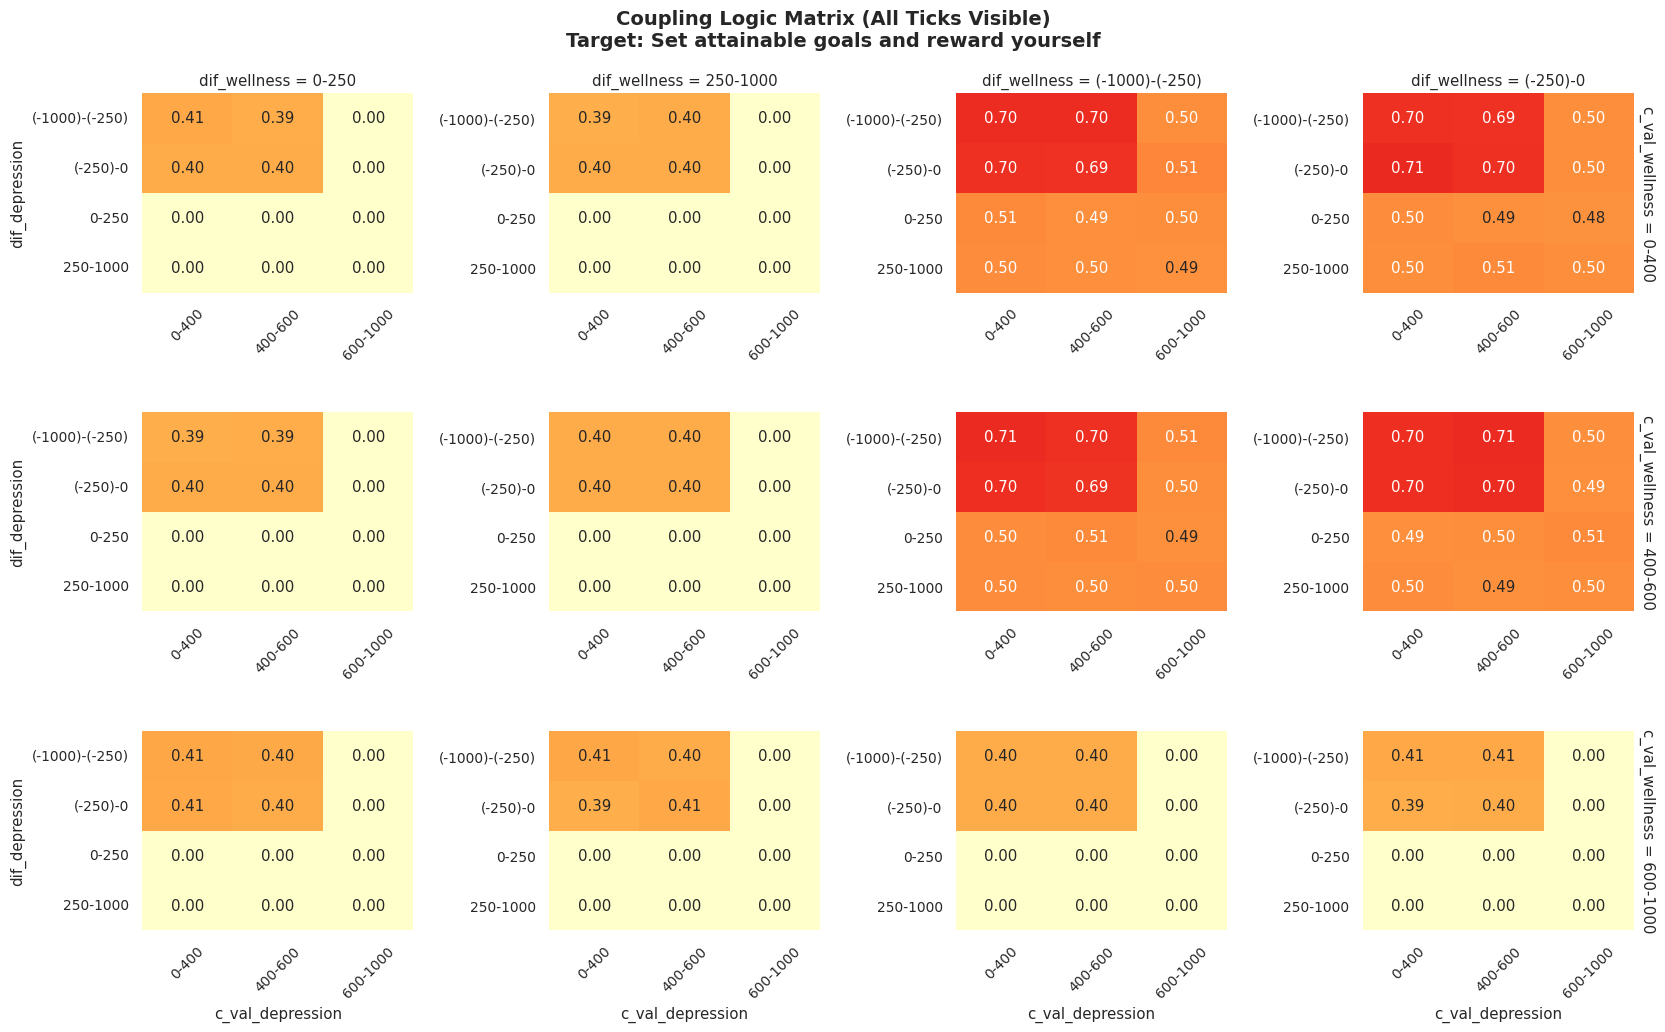

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

FILE_PATH = 'data_sample.xlsx'
DIM_COLS = ['c_val_wellness', 'dif_wellness', 'c_val_depression', 'dif_depression']
REQ_COL = 'recommendations'
TARGET_SNIPPET = "Set attainable goals and reward yourself"

logic_dist_df = None

def run_coupling_analysis_v3():
    global logic_dist_df
    
    print(f"Loading columns from {FILE_PATH}...")
    df_sub = pd.read_excel(FILE_PATH, usecols=DIM_COLS + [REQ_COL])
    
    df_sub['tip_present'] = df_sub[REQ_COL].str.contains(TARGET_SNIPPET, na=False).astype(int)
    
    print("Calculating frequency distribution table...")
    logic_dist_df = df_sub.groupby(DIM_COLS)['tip_present'].mean().reset_index()
    logic_dist_df.columns = DIM_COLS + ['appearance_probability']
    print("Generating visualized matrix...")
    sns.set_theme(style="white", font_scale=0.9)
    
    g = sns.FacetGrid(
        df_sub, 
        row='c_val_wellness', 
        col='dif_wellness', 
        margin_titles=True, 
        height=3.5, 
        aspect=1.2,
        despine=False 
    )

    def draw_heatmap(data, **kwargs):
        pivot = data.pivot_table(
            index='dif_depression', 
            columns='c_val_depression', 
            values='tip_present', 
            aggfunc='mean'
        )
        
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", 
                    vmin=0, vmax=1, cbar=False, **kwargs)
        
        plt.gca().tick_params(labelbottom=True, labelleft=True)
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)

    g.map_dataframe(draw_heatmap)

    plt.subplots_adjust(top=0.9, hspace=0.6, wspace=0.5) 
    g.fig.suptitle(f'Coupling Logic Matrix (All Ticks Visible)\nTarget: {TARGET_SNIPPET}', 
                   fontsize=14, fontweight='bold')
    
    plt.show()


run_coupling_analysis_v3()